In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import libraries
import os
from sklearn.metrics import classification_report
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [ ]:
# Load dataset and preprocess

image_dir = '/content/drive/MyDrive/Internship_Uzcosmos/datasets/dataset_train_test/train_images'
mask_dir = '/content/drive/MyDrive/Internship_Uzcosmos/datasets/dataset_train_test/train_masks'

images = []
labels = []

IMG_SIZE = 256
for file in os.listdir(image_dir):
    image_path = os.path.join(image_dir, file)
    mask_path = os.path.join(mask_dir, file)

    img = cv2.imread(image_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        print(f"Skipped: {file}")
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    # normalize
    img = img / 255.0
    mask = (mask > 127).astype(np.uint8)

    images.append(img)
    labels.append(mask)

images = np.array(images, dtype=np.float32)
labels = np.array(labels,  dtype=np.uint8)

print(images.shape)
print(labels.shape)

(2683, 256, 256, 3)
(2683, 256, 256)


In [ ]:
# Select features
X = images.reshape(-1, 3)
y = labels.reshape(-1)

print(f"X: {X.shape}")
print(f"y: {y.shape}")

sample_size = min(200000, len(X))
idx = np.random.choice(len(X), sample_size, replace=False)

X_sample = X[idx]
y_sample = y[idx]

X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

X: (175833088, 3)
y: (175833088,)


              precision    recall  f1-score   support

           0       0.82      0.85      0.83     26898
           1       0.66      0.62      0.64     13102

    accuracy                           0.77     40000
   macro avg       0.74      0.73      0.74     40000
weighted avg       0.77      0.77      0.77     40000



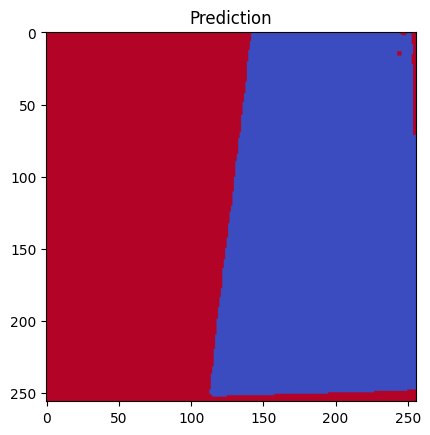

In [ ]:
# Select model
model = RandomForestClassifier(n_estimators=50, n_jobs=-1)
model.fit(X_train, y_train)

# predict
y_prediction = model.predict(X_test)

print(classification_report(y_test, y_prediction))
pred = model.predict(X[:images.shape[1]*images.shape[2]])

pred_img = pred.reshape(images.shape[1], images.shape[2])

# apply gaussian blur like to remove noise
clear_pred_img = cv2.medianBlur(pred_img.astype(np.uint8), 5)

# apply opening and closing for prediction
kernel = np.ones((3, 3), np.uint8)
cleared_pred_img = cv2.morphologyEx(clear_pred_img, cv2.MORPH_OPEN, kernel)
cleared_pred_img = cv2.morphologyEx(cleared_pred_img, cv2.MORPH_CLOSE, kernel)

plt.imshow(cleared_pred_img, cmap='coolwarm')
plt.title("Prediction")
plt.show()